In [45]:
 [
    "\"\"\"\n",
    "=============================================================================\n",
    "PROJETO: ChatMarket - Assistente Conversacional de Análise de Compras (N1)\n",
    "INSTITUIÇÃO: Universidade Presbiteriana Mackenzie\n",
    "CURSO: Bacharelado em Sistemas de Informação\n",
    "DISCIPLINA: Inteligência Artificial\n",
    "\n",
    "INTEGRANTES DO GRUPO:\n",
    "- Beatriz Pimenta de Camargo | RA: 10428378\n",
    "- Daniela Pereira da Silva | RA: 10410906\n",
    "- Ricardo Lins Pires | RA: 10419394\n",
    "- Valeria Oliveira de Almeida | RA: 10420562\n",
    "\n",
    "SÍNTESE DO CONTEÚDO:\n",
    "Este notebook executa o tratamento e a amostragem do conjunto de dados\n",
    "consolidado da Instacart, gerando a base final otimizada (instacart_1000.csv) \n",
    "utilizada pelo assistente conversacional no Chainlit.\n",
    "\n",
    "HISTÓRICO DE ATUALIZAÇÕES:\n",
    "- Data: 08/09/2026 | Autor: Beatriz Pimenta | Descrição: Estruturação inicial do pipeline de dados.\n",
    "- Data: 09/09/2026 | Autor: Beatriz Pimenta | Descrição: Filtragem da amostra de 1.000 linhas para o Chainlit.\n",
    "- Data: 10/09/2026 | Autor: Beatriz Pimenta | Descrição: Inclusão da documentação e cabeçalho de governança.\n",
    "- Data: 12/09/2026 | Autor: Daniela Pereira | Descrição: Inclusão da Análise Exploratória"
    "=============================================================================\n",
    "\"\"\""
   ]

['"""\n',
 '=============================================================================\n',
 'PROJETO: ChatMarket - Assistente Conversacional de Análise de Compras (N1)\n',
 'INSTITUIÇÃO: Universidade Presbiteriana Mackenzie\n',
 'CURSO: Bacharelado em Sistemas de Informação\n',
 'DISCIPLINA: Inteligência Artificial\n',
 '\n',
 'INTEGRANTES DO GRUPO:\n',
 '- Beatriz Pimenta de Camargo | RA: 10428378\n',
 '- Daniela Pereira da Silva | RA: 10410906\n',
 '- Ricardo Lins Pires | RA: 10419394\n',
 '- Valeria Oliveira de Almeida | RA: 10420562\n',
 '\n',
 'SÍNTESE DO CONTEÚDO:\n',
 'Este notebook executa o tratamento e a amostragem do conjunto de dados\n',
 'consolidado da Instacart, gerando a base final otimizada (instacart_1000.csv) \n',
 'utilizada pelo assistente conversacional no Chainlit.\n',
 '\n',
 'HISTÓRICO DE ATUALIZAÇÕES:\n',
 '- Data: 08/09/2026 | Autor: Beatriz Pimenta | Descrição: Estruturação inicial do pipeline de dados.\n',
 '- Data: 09/09/2026 | Autor: Beatriz Pimenta | 

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
# URL correta apontando para o arquivo na raiz do repositório público da Beatriz
url = "https://raw.githubusercontent.com/bpdc/ChatMarket/main/instacart_1000.csv"
df_arquivo_final = pd.read_csv(url)

print("Base carregada com sucesso!")
display(df_arquivo_final.head(3))

Base carregada com sucesso!


,order_id,product_name,department,aisle,order_dow,order_hour_of_day,days_since_prior_order,reordered
0,1,Bulgarian Yogurt,dairy eggs,yogurt,4,10,9.0,1
1,1,Organic 4% Milk Fat Whole Milk Cottage Cheese,dairy eggs,other creams cheeses,4,10,9.0,1
2,1,Organic Celery Hearts,produce,fresh vegetables,4,10,9.0,0


# ANÁLISE EXPLORATÓRIA DOS DADOS

In [32]:

print("--- INFORMAÇÕES DO DATASET ---")
df_arquivo_final.info()

print("\n--- RESUMO ESTATÍSTICO ---")
display(df_arquivo_final.describe())

print("\n--- VALORES NULOS ---")
print(df_arquivo_final.isnull().sum())

--- INFORMAÇÕES DO DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                1000 non-null   int64  
 1   product_name            1000 non-null   object 
 2   department              1000 non-null   object 
 3   aisle                   1000 non-null   object 
 4   order_dow               1000 non-null   int64  
 5   order_hour_of_day       1000 non-null   int64  
 6   days_since_prior_order  1000 non-null   float64
 7   reordered               1000 non-null   int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 62.6+ KB

--- RESUMO ESTATÍSTICO ---


,order_id,order_dow,order_hour_of_day,days_since_prior_order,reordered
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1656.994000,2.585000,13.189000,17.482000,0.569000
std,940.337729,2.071972,3.806543,10.535876,0.495464
min,1.000000,0.000000,6.000000,0.000000,0.000000
25%,1032.000000,1.000000,10.000000,7.000000,0.000000
50%,1620.000000,2.000000,13.000000,14.000000,1.000000
75%,2445.000000,5.000000,16.000000,30.000000,1.000000
max,3209.000000,6.000000,23.000000,30.000000,1.000000



--- VALORES NULOS ---
order_id                  0
product_name              0
department                0
aisle                     0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
reordered                 0
dtype: int64


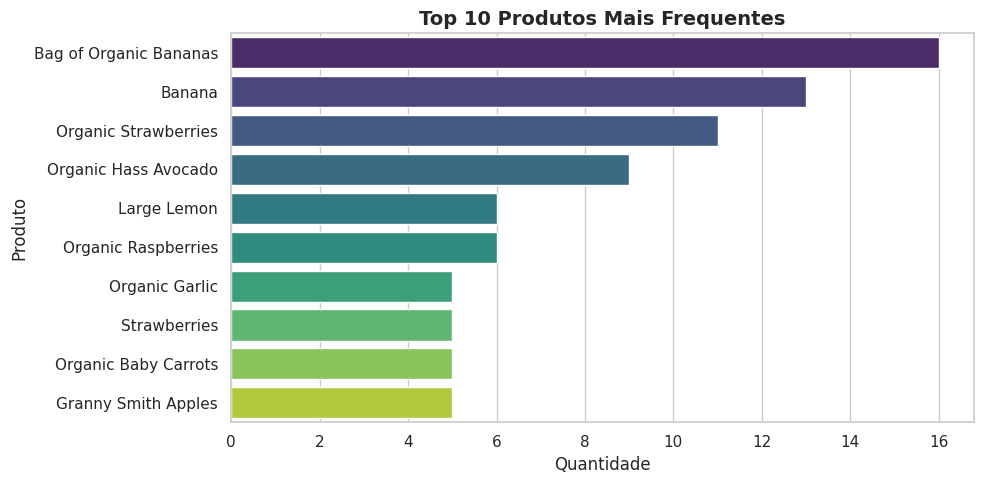

In [33]:
# VISUALIZAÇÕES GRÁFICAS
sns.set_theme(style="whitegrid")

# Gráfico 1: Top Produtos
plt.figure(figsize=(10, 5))
top_produtos = df_arquivo_final['product_name'].value_counts().head(10)
sns.barplot(x=top_produtos.values, y=top_produtos.index, hue=top_produtos.index, palette='viridis', legend=False)
plt.title('Top 10 Produtos Mais Frequentes', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade')
plt.ylabel('Produto')
plt.tight_layout()
plt.show()



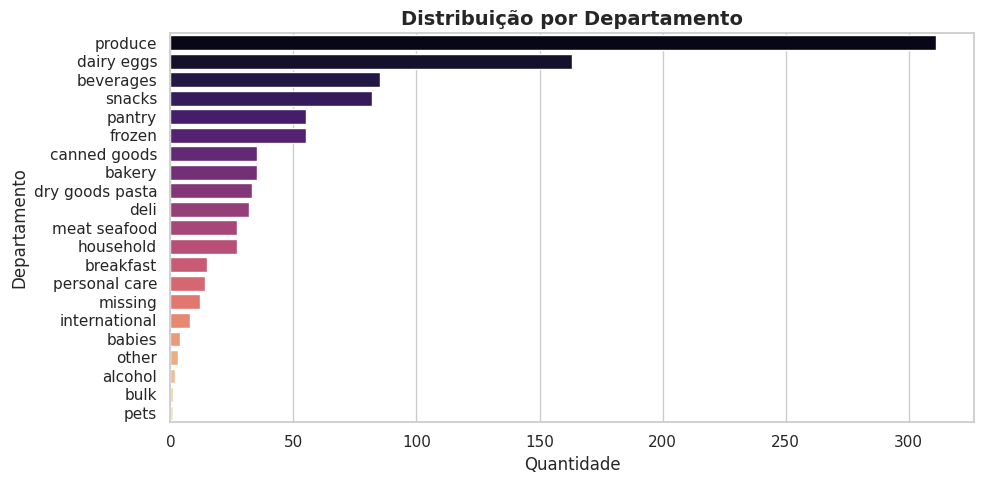

In [34]:
# Gráfico 2: Departamentos
plt.figure(figsize=(10, 5))
top_deps = df_arquivo_final['department'].value_counts()
sns.barplot(x=top_deps.values, y=top_deps.index, hue=top_deps.index, palette='magma', legend=False)
plt.title('Distribuição por Departamento', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()